In [3]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## LOADING MODEL

In [4]:
model = tf.keras.models.load_model('trained_model.keras')

In [5]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_102 (Conv2D)         (None, 128, 128, 32)      896       
                                                                 
 conv2d_103 (Conv2D)         (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_32 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_104 (Conv2D)         (None, 63, 63, 64)        18496     
                                                                 
 conv2d_105 (Conv2D)         (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_33 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                 

In [16]:
##Visualizing single image of test set

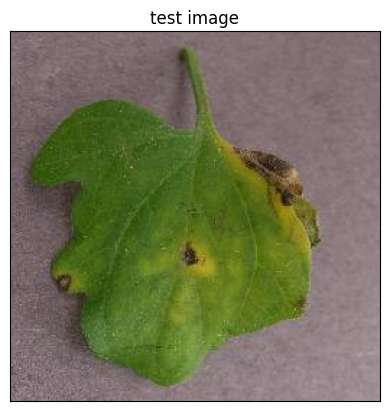

In [6]:
import cv2
image_path = "Test/Septoria Leaf Spot/1bd1e4bf-3f5e-4954-a265-edb058f2db96___Matt.S_CG 1215_180deg.JPG"
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.xticks([])
plt.yticks([])
plt.imshow(img)
plt.title("test image")
plt.show()

In [7]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size = (128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])
print(input_arr.shape)

(1, 128, 128, 3)


In [8]:
prediction = model.predict(input_arr)
prediction

1/1 [==============================] - 7s 7s/step


array([[1.9049992e-04, 2.6516728e-03, 7.5895077e-06, 7.5046897e-05,
        9.8557407e-01, 1.1501217e-02]], dtype=float32)

In [9]:
result_index = np.argmax(prediction)
result_index

4

In [10]:
class_name = ['Bacterial_spot','early_blight','healthy','Late_blight','Septoria_leaf_spots','Yellow_leaf_curl_virus']

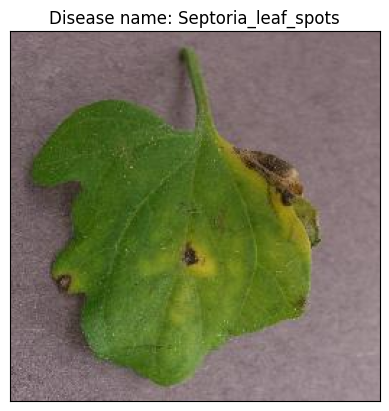

In [11]:
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [12]:
model_prediction

'Septoria_leaf_spots'